In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from config import BENCHMARKS
from utils import plot_pool_distribution
from sensitivity_analysis.sensitivity_utils import load_scores, sweep_thresholds, plot_sweep

BENCHMARK = "PERIODIC_SPACES"
BENCH_PARAMS = BENCHMARKS[BENCHMARK]
METRIC_COL = BENCH_PARAMS["metric_col"]
THRESHOLD = BENCH_PARAMS["threshold"]
METRIC_OP = BENCH_PARAMS["metric_op"]
SAMPLE_SIZE = BENCH_PARAMS["sample_size"]
SPARSITY_MIN = BENCH_PARAMS["sparsity_min"]
SPARSITY_MAX = BENCH_PARAMS["sparsity_max"]
XLABEL = f"Max |ACF| of binary (zero/non-zero) series (lags 1–{int(BENCH_PARAMS['max_lag_factor'])})"

SOURCES = [("ips_full", "IPs")]
SWEEP_RANGE = np.arange(0.40, 0.81, 0.025)

plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

GRAPH_DIR = Path('sensitivity_analysis/figures')
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

print(f"Benchmark: {BENCHMARK}")
print(f"Threshold: {METRIC_COL} {METRIC_OP} {THRESHOLD}")
print(f"Activity band: [{SPARSITY_MIN}, {SPARSITY_MAX}]")
print(f"Sample size: {SAMPLE_SIZE}")

Benchmark: PERIODIC_SPACES
Threshold: max_acf >= 0.6
Activity band: [0.05, 0.95]
Sample size: 25


## Hourly

In [2]:
print("Loading hourly scores:")
scores_hourly_raw = load_scores("hourly", BENCHMARK, SOURCES)

scores_hourly = {}
for label, df in scores_hourly_raw.items():
    in_band = df["ratio_active"].between(SPARSITY_MIN, SPARSITY_MAX)
    filtered = df[in_band].copy()
    print(f"  {label}: {len(filtered)}/{len(df)} pass activity band [{SPARSITY_MIN}, {SPARSITY_MAX}]")
    scores_hourly[label] = filtered

Loading hourly scores:
  IPs: 275124 series
  IPs: 134241/275124 pass activity band [0.05, 0.95]


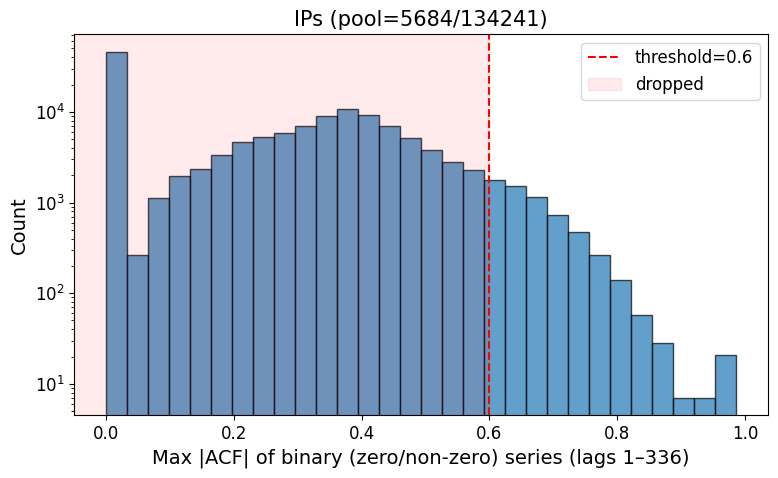

In [3]:
plot_pool_distribution(
    [(scores_hourly[label], label) for _, label in SOURCES],
    metric_col=METRIC_COL,
    threshold=THRESHOLD,
    metric_op=METRIC_OP,
    xlabel=XLABEL,
    log_y=True,
    save_path=GRAPH_DIR / f"{BENCHMARK}_pool_distribution_hourly.pdf",
)

In [4]:
sweep_hourly = sweep_thresholds(scores_hourly, METRIC_COL, SWEEP_RANGE, metric_op=METRIC_OP)
display(sweep_hourly)

,threshold,IPs pool,IPs median
0,0.40,34652,0.477
1,0.43,27619,0.502
2,0.45,22092,0.528
3,0.48,17662,0.554
4,0.50,14132,0.578
5,0.53,11348,0.600
6,0.55,9121,0.622
7,0.58,7288,0.641
8,0.60,5684,0.659
9,0.63,4411,0.677


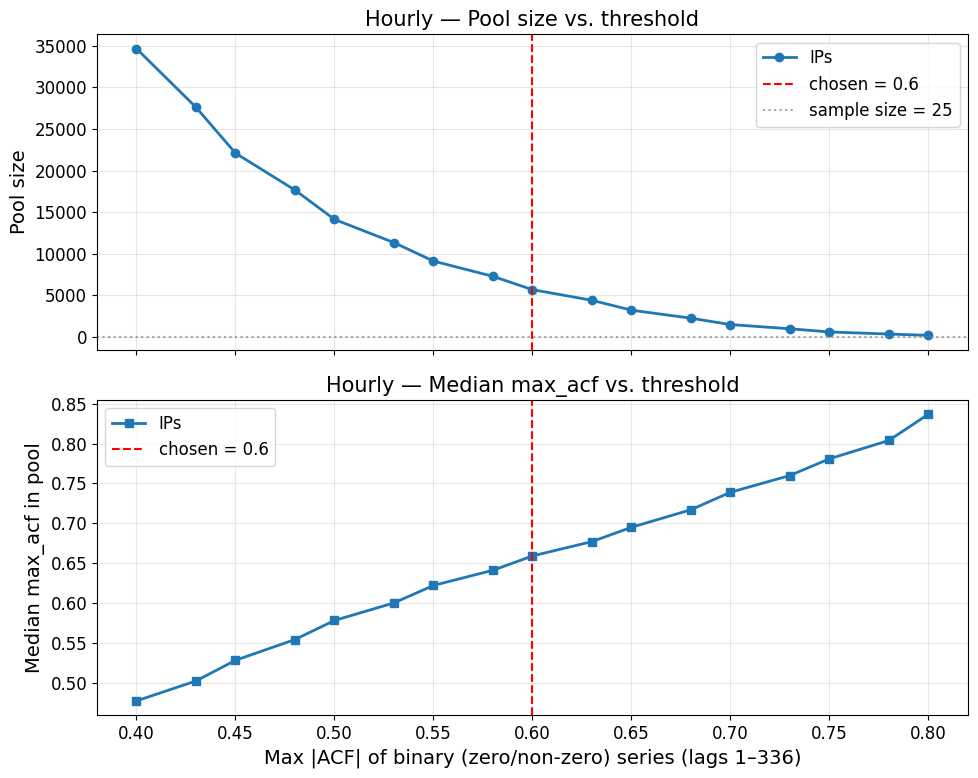

In [5]:
plot_sweep(sweep_hourly, "Hourly", THRESHOLD, SAMPLE_SIZE, XLABEL, METRIC_COL,
           save_path=GRAPH_DIR / f"{BENCHMARK}_sweep_hourly.pdf")

### Activity-Band Sensitivity

Compare the current band `[0.05, 0.95]` against a tighter band `[0.10, 0.90]` at the current ACF threshold (0.60). Check whether any of the 25 selected IPs would be excluded under the tighter band.

In [6]:
BANDS = {
    "(a) [0.05, 0.95] (current)": (0.05, 0.95),
    "(b) [0.10, 0.90] (tighter)": (0.10, 0.90),
}


def band_analysis(scores_df, id_col, selected_ids, label):
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    for band_name, (lo, hi) in BANDS.items():
        in_band = scores_df[scores_df["ratio_active"].between(lo, hi)]
        pool = in_band[in_band[METRIC_COL] >= THRESHOLD]
        print(f"\n  {band_name}:")
        print(f"    In activity band: {len(in_band)}")
        print(f"    Pool ({METRIC_COL} ≥ {THRESHOLD}): {len(pool)}")

    lo_tight, hi_tight = BANDS["(b) [0.10, 0.90] (tighter)"]
    selected_rows = scores_df[scores_df[id_col].isin(selected_ids)]
    excluded = selected_rows[~selected_rows["ratio_active"].between(lo_tight, hi_tight)]
    if len(excluded) == 0:
        print(f"\n  → No selected IDs excluded under tighter band — band is non-binding.")
    else:
        print(f"\n  → {len(excluded)} selected ID(s) would be EXCLUDED under tighter band:")
        display(excluded[[id_col, "ratio_active", METRIC_COL]])


selected_hourly = pd.read_csv(f"selected_ids/hourly/{BENCHMARK}.csv")["ts_id"].tolist()
band_analysis(scores_hourly_raw["IPs"], "id_ip", selected_hourly, "Hourly — IPs")


  Hourly — IPs

  (a) [0.05, 0.95] (current):
    In activity band: 134241
    Pool (max_acf ≥ 0.6): 5684

  (b) [0.10, 0.90] (tighter):
    In activity band: 98866
    Pool (max_acf ≥ 0.6): 5050

  → 5 selected ID(s) would be EXCLUDED under tighter band:


,id_ip,ratio_active,max_acf
40370,162890.0,0.071748,0.665215
40916,165515.0,0.076362,0.648545
56670,237694.0,0.073980,0.691951
150075,722293.0,0.076511,0.817223
186015,1536107.0,0.051801,0.637951


## 10-Minute

In [7]:
print("Loading 10-minute scores:")
scores_10min_raw = load_scores("10min", BENCHMARK, SOURCES)

scores_10min = {}
for label, df in scores_10min_raw.items():
    in_band = df["ratio_active"].between(SPARSITY_MIN, SPARSITY_MAX)
    filtered = df[in_band].copy()
    print(f"  {label}: {len(filtered)}/{len(df)} pass activity band [{SPARSITY_MIN}, {SPARSITY_MAX}]")
    scores_10min[label] = filtered

Loading 10-minute scores:
  IPs: 275124 series
  IPs: 133780/275124 pass activity band [0.05, 0.95]


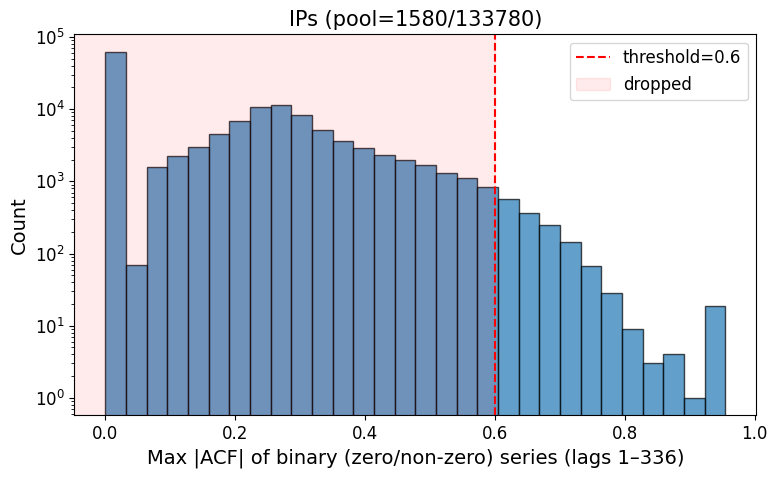

In [8]:
plot_pool_distribution(
    [(scores_10min[label], label) for _, label in SOURCES],
    metric_col=METRIC_COL,
    threshold=THRESHOLD,
    metric_op=METRIC_OP,
    xlabel=XLABEL,
    log_y=True,
    save_path=GRAPH_DIR / f"{BENCHMARK}_pool_distribution_10min.pdf",
)

In [9]:
sweep_10min = sweep_thresholds(scores_10min, METRIC_COL, SWEEP_RANGE, metric_op=METRIC_OP)
display(sweep_10min)

,threshold,IPs pool,IPs median
0,0.40,11888,0.486
1,0.43,9845,0.505
2,0.45,8113,0.524
3,0.48,6537,0.545
4,0.50,5179,0.563
5,0.53,4030,0.583
6,0.55,3075,0.602
7,0.58,2229,0.622
8,0.60,1580,0.645
9,0.63,1061,0.668


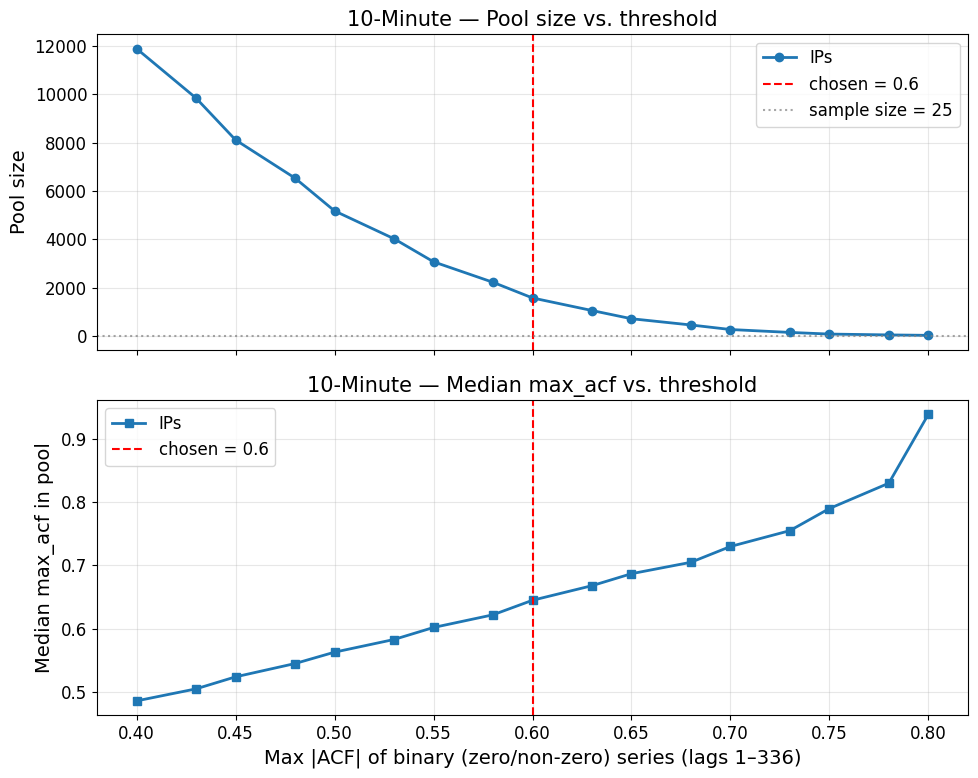

In [10]:
plot_sweep(sweep_10min, "10-Minute", THRESHOLD, SAMPLE_SIZE, XLABEL, METRIC_COL,
           save_path=GRAPH_DIR / f"{BENCHMARK}_sweep_10min.pdf")

### Activity-Band Sensitivity

In [11]:
selected_10min = pd.read_csv(f"selected_ids/10min/{BENCHMARK}.csv")["ts_id"].tolist()
band_analysis(scores_10min_raw["IPs"], "id_ip", selected_10min, "10-Minute — IPs")


  10-Minute — IPs

  (a) [0.05, 0.95] (current):
    In activity band: 133780
    Pool (max_acf ≥ 0.6): 1580

  (b) [0.10, 0.90] (tighter):
    In activity band: 81487
    Pool (max_acf ≥ 0.6): 1351

  → 4 selected ID(s) would be EXCLUDED under tighter band:


,id_ip,ratio_active,max_acf
34733,137398.0,0.063055,0.719602
67522,288065.0,0.098193,0.701246
68342,292005.0,0.095712,0.692559
273635,2003176.0,0.085166,0.605613
